# MLP (PyTorch) e MLflow

Mesmo **pré-processamento** dos baselines (`ColumnTransformer` em `baselines.py`). A rede (`ChurnMLP` em `mlp.py`) vê só números já imputados e escalados / *one-hot*.

Treino com **holdout estratificado** (80% treino / 20% validação) e **early stopping** quando a **PR-AUC** na validação não melhora durante várias épocas. `BCEWithLogitsLoss` usa `pos_weight` para compensar o desequilíbrio.

**Métricas** no conjunto de validação (melhor *checkpoint* por PR-AUC): ROC-AUC, PR-AUC, F1 no corte 0,5, *balanced accuracy*, e **`f1_at_threshold_start`** com o limiar de `config.py` / `metricas_e_limiar.md`.

**Como rodar:** raiz do repo ou pasta `notebooks/` — a primeira célula ajusta `sys.path` e o MLflow usa `mlruns/` na raiz.


In [ ]:
# Raiz do repositório
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
from sklearn.model_selection import train_test_split

from churn_prediction.config import (
    MLFLOW_EXPERIMENT_MLP,
    RANDOM_SEED,
    THRESHOLD_START,
)
from churn_prediction.datasets import load_churn_telco, make_X_y
from churn_prediction.mlp import train_churn_mlp

mlflow.set_tracking_uri(f"file:{ROOT / 'mlruns'}")
mlflow.set_experiment(MLFLOW_EXPERIMENT_MLP)


C:\Users\Primodeckers\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/03 20:25:30 INFO mlflow.tracking.fluent: Experiment with name 'telco_churn_mlp' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:d:\\tech-challenge-fase-one\\tech_challenge_fase_01\\mlruns/538271442616915894', creation_time=1777850730393, experiment_id='538271442616915894', last_update_time=1777850730393, lifecycle_stage='active', name='telco_churn_mlp', tags={}, trace_location=None, workspace='default'>

## Carregar dados

Mesmo fluxo do notebook `02_baselines_mlflow.ipynb`: Excel em `data/raw/`, `Total Charges` limpo, `make_X_y` sem colunas de *leakage*.


In [ ]:
path = ROOT / "data" / "raw" / "Telco_customer_churn.xlsx"

import hashlib


def _file_sha256(p: Path) -> str:
    h = hashlib.sha256()
    with p.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


DATASET_SHA256 = _file_sha256(path)

df = load_churn_telco(path)
X, y = make_X_y(df)
print("Shape X:", X.shape, "| churn %:", round(y.mean() * 100, 2))


Shape X: (7032, 26) | churn %: 26.58


## Treino com validação e early stopping

Hiperparâmetros abaixo são um ponto de partida; pode alterar `hidden_layers`, `dropout`, `lr`, etc. e registar no MLflow.


Métricas (validação, melhor época por PR-AUC):
  average_precision: 0.6224232782671941
  balanced_accuracy: 0.7463413245259382
  best_epoch: 2.0
  epochs_trained: 22.0
  f1_at_threshold_start: 0.5917602996254682
  f1_default_threshold: 0.6078639744952179
  roc_auc: 0.8366033203741762


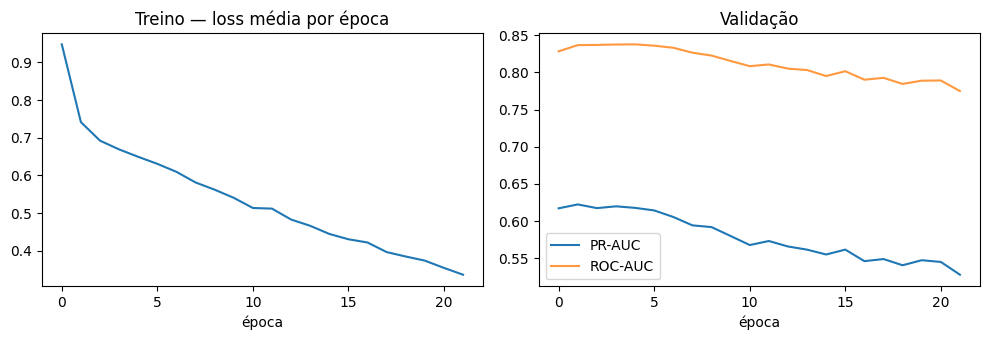

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y,
)

result = train_churn_mlp(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layers=(128, 64),
    dropout=0.2,
    lr=1e-3,
    batch_size=256,
    max_epochs=200,
    patience=20,
    min_epochs=5,
    random_seed=RANDOM_SEED,
)

print("Métricas (validação, melhor época por PR-AUC):")
for k, v in sorted(result.metrics.items()):
    print(f"  {k}: {v}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(result.history["train_loss"])
axes[0].set_title("Treino — loss média por época")
axes[0].set_xlabel("época")
axes[1].plot(result.history["val_avg_precision"], label="PR-AUC")
axes[1].plot(result.history["val_roc_auc"], label="ROC-AUC", alpha=0.8)
axes[1].set_title("Validação")
axes[1].set_xlabel("época")
axes[1].legend()
plt.tight_layout()
plt.show()


## MLflow

Um *run* por execução completa. Compare com o experimento `telco_churn_baselines` no mesmo `mlflow ui`.


In [ ]:
with mlflow.start_run(run_name="mlp_dropout02"):
    mlflow.log_params(
        {
            "random_seed": RANDOM_SEED,
            "test_size_val": 0.2,
            "hidden_layers": "(128, 64)",
            "dropout": 0.2,
            "lr": 1e-3,
            "batch_size": 256,
            "threshold_start": THRESHOLD_START,
            "dataset_file": path.name,
            "dataset_sha256": DATASET_SHA256,
            "n_train": len(X_train),
            "n_val": len(X_val),
        }
    )
    for name, val in result.metrics.items():
        mlflow.log_metric(name, float(val))

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experimento:", MLFLOW_EXPERIMENT_MLP)


Tracking URI: file:d:\tech-challenge-fase-one\tech_challenge_fase_01\mlruns
Experimento: telco_churn_mlp
